In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#надо загрузить данные из датасета
df = pd.read_excel('Telco_customer_churn.xlsx')

#проверю загрузку на всякий случай
print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
display(df.head())



Размер данных: (7043, 33)

Первые 5 строк:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


1. Постановка задачи
*   Бизнес-постановка: Вымышленная-телеком компания теряет клиентов, привлечение нового клиента дороже, чем удержание старого. Таким образом, **Бизнес-цель: выявить клиентов, склонных к уходу, чтобы вовремя предложить им личные условия (скидки акции итд), сохарнить клиента и выручку.**
*   ML-постановка (бинарная классификация): Целевая переменная: Churn Value (1 - ушел, 0 - остался). Признаки: демографические данные, информация об услугах, данные о контракте и платежах (признаки Churn Score и Churn Reason не будут учитываться, поскольку они становятся известны уже после ухода).
*   Набор данных: Датасет Telco Customer Churn содtржит достаточно информации (>7 тыс строк).
2. Выбор метрики
*   Основная метрика: F1-мера (среднее гармоническое между точностью и полнотой), дополнительная метрика: ROC-AUC (функция зависимости ложных и правильных срабатываний, а также площадь под этим графиком)
*   Обоснование: В датасете наблюдается дисбаланс классов. Метрика Точность в какой-то мере бесполезна, поскольку модель, предсказывающая событие "Все останутся" даст высокую точность, но не будет иметь пользы для бизнеса. Также, цена ошибок не симметрична: Ложно-отрицательное значение - модель предсказала, что клиент остался, а он ушел, бизнес теряет клиента и всю будущую выручку. Ложно-положительное значение - модель предсказала уход, а клиент остался. Бизнес теряет деньги на не нужное удержание клиента, который и так не собирался уходить. Будущая выручка сохранена, однако произошли потери не не нужное привлечение. Таким образом, нам важна высокая Полнота по классу 1, также как и высокая Точность. F1-мера идеально балансирует эти метрики.





Так как в столбце Total Charges имеются пустые ячейки, необходима предобработка данных. Эти пустые ячейки появились из-за совсем недавнего подключения клиентов.

In [ ]:
#преобразую Total Charges в числовой формат, чтобы пустые ячейки стали NaN
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors = 'coerce')

#заполню пропуски нулем, так как у новых клиентов еще нет платежей
df['Total Charges'] = df['Total Charges'].fillna(0)

#проверю что пропуски исчезли
print("Пропуски после обработки:", df['Total Charges'].isnull().sum())


Пропуски после обработки: 0


In [ ]:
#базовая статистика
print("Размер данных:", df.shape)
print("\nПропуски в данных после обработки:", df.isnull().sum().sum())
print("\nСтатистика по числовым признакам:")
display(df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']].describe())


Размер данных: (7043, 33)

Пропуски в данных после обработки: 5174

Статистика по числовым признакам:


,Tenure Months,Monthly Charges,Total Charges,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,4400.295755
std,24.559481,30.090047,2266.794470,1183.057152
min,0.000000,18.250000,0.000000,2003.000000
25%,9.000000,35.500000,398.550000,3469.000000
50%,29.000000,70.350000,1394.550000,4527.000000
75%,55.000000,89.850000,3786.600000,5380.500000
max,72.000000,118.750000,8684.800000,6500.000000


Эти пропуски - это пропуски в колонке причины ухода (Churn Reason). Необходимо удалить лишние и бесполезные столбцы, такие как: Churn Reason (известна уже после ухода), Churn Score (известно тоже уже после ухода), CustomerID (номер, который создает визуальный шум и перегружает таблицу).

In [ ]:
#Создам список столбцов для удаления
columns_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'Lat Long', 'Churn Label', 'Churn Score', 'Churn Reason']
df = df.drop(columns=columns_to_drop, errors='ignore')

#проверю оставшиеся колонки
print("Оставшиеся колонки:")
print(df.columns.tolist())

print("\nРазмер данных после удаления лишних столбцов:", df.shape)


Оставшиеся колонки:
['City', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']

Размер данных после удаления лишних столбцов: (7043, 25)


Визуализации данных:

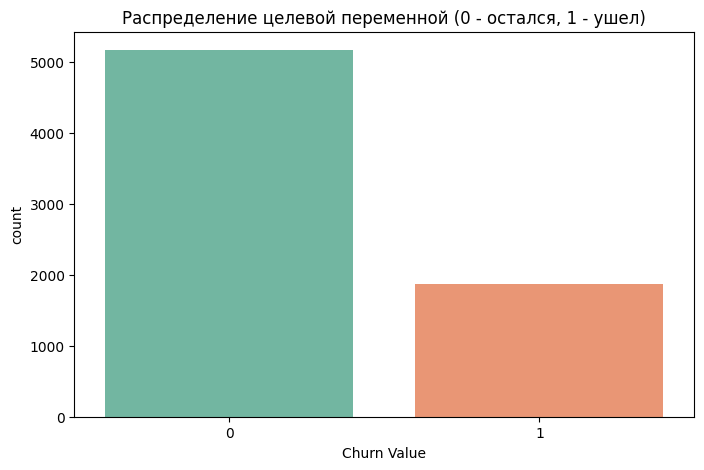

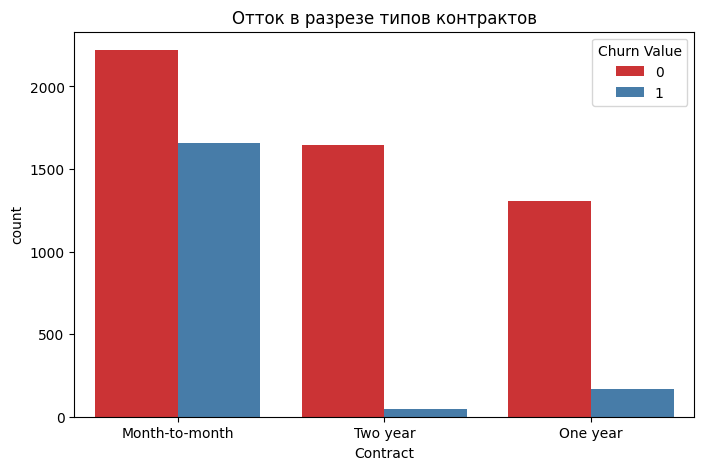

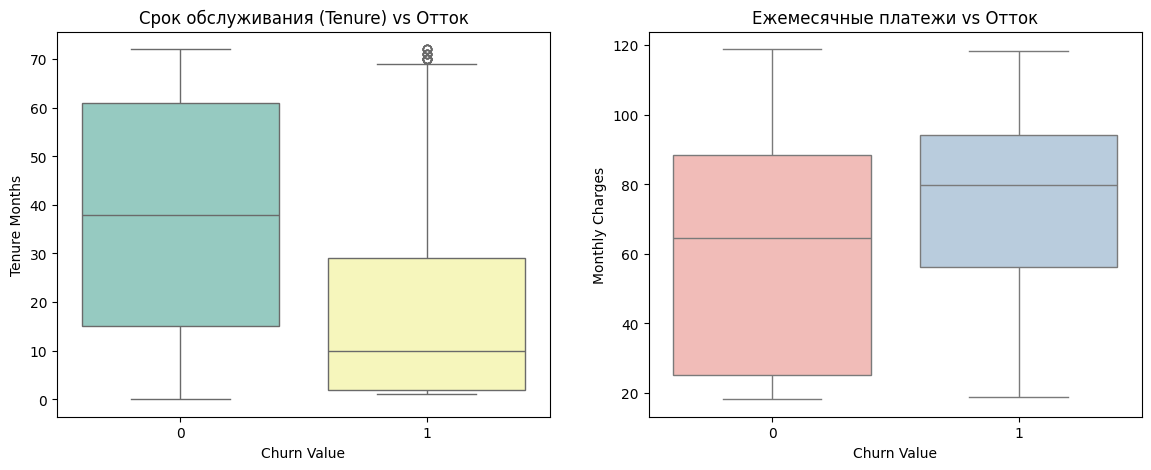

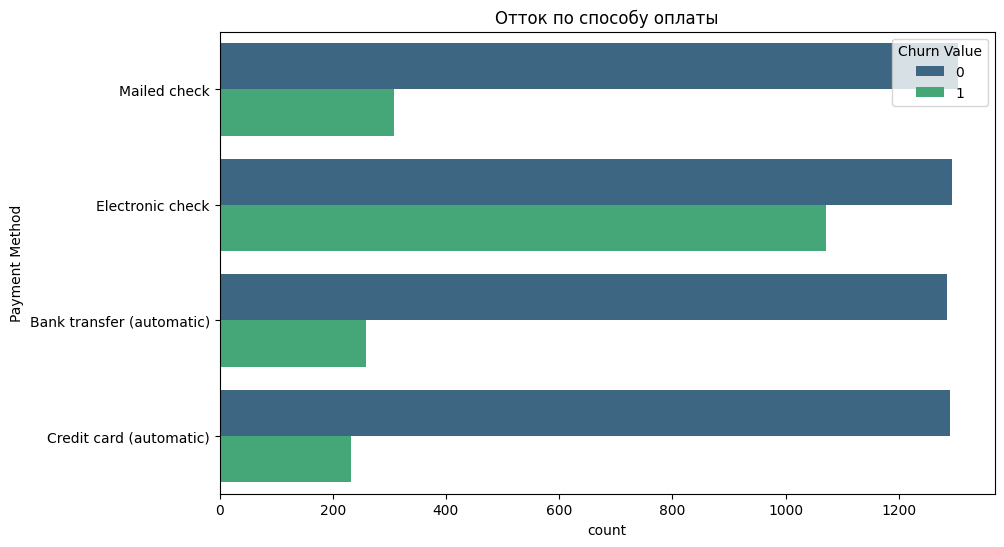

In [ ]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8, 5) #размер по умолчанию

#дисбаланс классов
plt.figure()
sns.countplot(x='Churn Value', data=df, palette='Set2', hue='Churn Value', legend=False)
plt.title('Распределение целевой переменной (0 - остался, 1 - ушел)')
plt.show()

#влияние типа контракта
plt.figure()
sns.countplot(x='Contract', hue='Churn Value', data=df, palette='Set1')
plt.title('Отток в разрезе типов контрактов')
plt.show()

#влияние срока обслуживания и платежей
matplotlib.rcParams['figure.figsize'] = (14, 5)
fig, axes = plt.subplots(1, 2)
sns.boxplot(x='Churn Value', y='Tenure Months', data=df, palette='Set3',
hue='Churn Value', legend=False, ax=axes[0])
axes[0].set_title('Срок обслуживания (Tenure) vs Отток')
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df, palette='Pastel1',
hue='Churn Value', legend=False, ax=axes[1])
axes[1].set_title('Ежемесячные платежи vs Отток')
plt.show()

#влияние способа оплаты
matplotlib.rcParams['figure.figsize'] = (10, 6)
plt.figure()
sns.countplot(y='Payment Method', hue='Churn Value', data=df, palette='viridis')
plt.title('Отток по способу оплаты')
plt.show()

1. Дисбаланс классов: примерно 25% ушедших и 75% оставшихся. Метрика Точность неприменима, необходимо использовать F1-меру.
2. Тип контракта: чаще всего уходят клиенты с оплатой каждый месяц, реже всего - двухлетник контракты.
3. Срок обслуживания:основной отток среди недавних клиентов, медиана ушедших - примерно 10 месяцев, оставшихся - 37 месяцев.
4. Ежемесячные платежи: ушедшие платили больше (медиана около 80), оставшиеся платят меньше (медиана около 63).
5. Способ оплаты: клиенты с электронным чеком уходят чаще.

Таким образом, бизнесу нужен усиленный онбординг для уменьшения оттока новичков, снижать цену насколько это возможно без потери качества услуг, а также максимально переводить клиентов на автоплатеж.